In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.feature_selection import SequentialFeatureSelector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Get data

In [5]:
data = pd.read_csv("../../Data/cleaned_data_classification_all_decades.csv")
X = data.drop('target', axis=1)
y = data['target']

Default parameters

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


              precision    recall  f1-score   support

           0       0.85      0.76      0.80      2730
           1       0.78      0.86      0.81      2607

    accuracy                           0.81      5337
   macro avg       0.81      0.81      0.81      5337
weighted avg       0.81      0.81      0.81      5337

Confusion Matrix:
[[2080  650]
 [ 367 2240]]
Accuracy: 0.8094435075885329
F1 Score: 0.8091403096345119


test_size = 0.2

Accuracy: 0.8147835862844295
F1 Score: 0.814686611160581

Look for best parameters

In [7]:
#get grid search cv for random forest
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [200, 300, 350],
    'max_depth': [8, 10, 15, 20],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best, average='weighted'))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.87      0.74      0.80      2730
           1       0.77      0.88      0.82      2607

    accuracy                           0.81      5337
   macro avg       0.82      0.81      0.81      5337
weighted avg       0.82      0.81      0.81      5337

Confusion Matrix:
[[2022  708]
 [ 300 2307]]
Accuracy: 0.8111298482293423
F1 Score: 0.8103566084837814


Try forward feature selection

In [8]:
#feature selection with sequential feature selector
#get features with correlation > 0.05 with target
all_features_df = pd.read_csv('../../Data/cleaned_data_classification_all_decades_all_features.csv')
columns_corr = all_features_df.columns[all_features_df.corr()['target'].abs() > 0.05].tolist()
columns_corr.remove('target')
print("Columns with correlation > 0.05:", columns_corr)
X = all_features_df[columns_corr]
y = all_features_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Columns with correlation > 0.05: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'duration_ms', 'time_signature', 'chorus_hit', 'sections']


In [9]:
model = RandomForestClassifier(max_depth=15, min_samples_leaf=1, min_samples_split=4, n_estimators=300, random_state=42) #get the best parameters from grid search
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
sfs = SequentialFeatureSelector(model, direction='forward')
sfs.fit(X_train, y_train)

    

,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",'auto'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4


In [10]:
#print the selected features
print("Selected features:", sfs.get_support())
feature_set = [col for col, selected in zip(columns_corr, sfs.get_support()) if selected]
print("Selected features:", feature_set)

Selected features: [ True  True  True False  True  True False False  True False False False]
Selected features: ['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'duration_ms']


TEST NEW FEATURES

In [11]:
X = all_features_df[feature_set]
y = all_features_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


              precision    recall  f1-score   support

           0       0.88      0.77      0.82      2730
           1       0.79      0.89      0.83      2607

    accuracy                           0.83      5337
   macro avg       0.83      0.83      0.83      5337
weighted avg       0.83      0.83      0.83      5337

Confusion Matrix:
[[2108  622]
 [ 299 2308]]
Accuracy: 0.8274311410905003
F1 Score: 0.8270392089709566


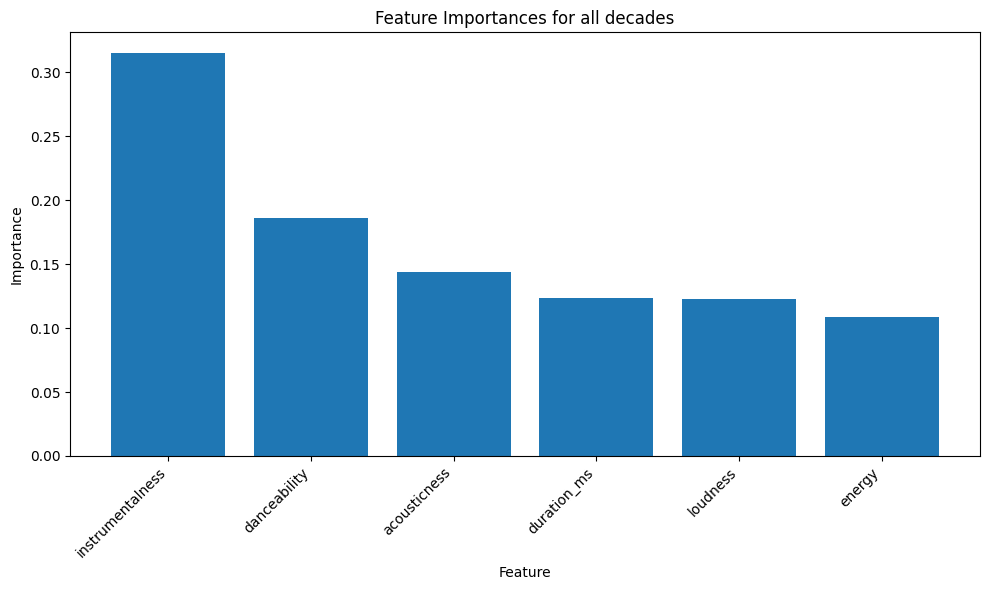

In [12]:
#get feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances for all decades")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_set[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()
#plt.savefig('../../Figures/feature_importance_all_decades.png')


CHECK FEATURE IMPORTANCE FOR DIFFERENT DECADES

90s Features


In [13]:
data_90s = pd.read_csv('../../Data/dataset-of-90s.csv')
columns_corr = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target']


# Calculate correlations and identify best features
data_num = data_90s[columns_corr]
data_90s.head()


,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [14]:
#feature selection with sequential feature selector
#get features with correlation > 0.05 with target

columns_corr = data_num.columns[data_num.corr()['target'].abs() > 0.05].tolist()
columns_corr.remove('target')
print("Columns with correlation > 0.05:", columns_corr)
X = data_num[columns_corr]
y = data_num['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Columns with correlation > 0.05: ['danceability', 'energy', 'key', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'duration_ms', 'time_signature']


In [15]:
model = RandomForestClassifier(max_depth=15, min_samples_leaf=1, min_samples_split=4, n_estimators=300, random_state=42) #get the best parameters from grid search
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
sfs = SequentialFeatureSelector(model, direction='forward')
sfs.fit(X_train, y_train)


,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",'auto'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4


In [16]:
#print the selected features
print("Selected features:", sfs.get_support())
feature_set = [col for col, selected in zip(columns_corr, sfs.get_support()) if selected]
print("Selected features:", feature_set)

Selected features: [ True False False False  True  True  True False False  True False]
Selected features: ['danceability', 'speechiness', 'acousticness', 'instrumentalness', 'duration_ms']


In [17]:
X = all_features_df[feature_set]
y = all_features_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      2730
           1       0.78      0.88      0.83      2607

    accuracy                           0.82      5337
   macro avg       0.83      0.82      0.82      5337
weighted avg       0.83      0.82      0.82      5337

Confusion Matrix:
[[2073  657]
 [ 301 2306]]
Accuracy: 0.8204984073449504
F1 Score: 0.8199746762442137


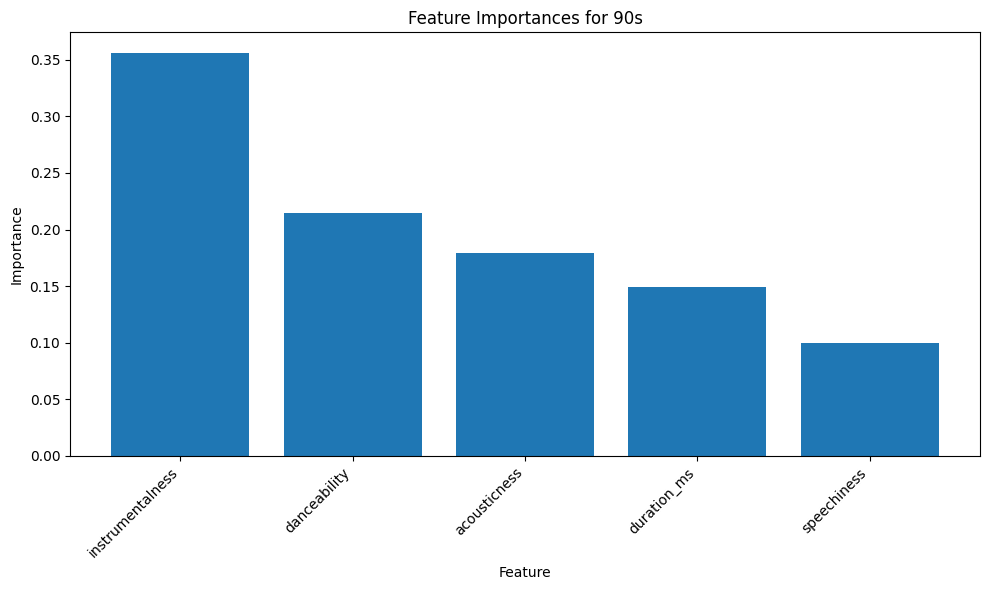

In [18]:
#get feature importance
importances_90s = model.feature_importances_
indices = np.argsort(importances_90s)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances for 90s")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.bar(range(len(importances_90s)), importances_90s[indices])
plt.xticks(range(len(importances_90s)), [feature_set[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../../Figures/feature_importance_90s.png')
plt.show()

00s Features


In [19]:
data_00s = pd.read_csv('../../Data/dataset-of-00s.csv')
columns_corr = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target']


# Calculate correlations and identify best features
data_num = data_00s[columns_corr]
#data_00s.head()


In [20]:
#feature selection with sequential feature selector
#get features with correlation > 0.05 with target

columns_corr = data_num.columns[data_num.corr()['target'].abs() > 0.05].tolist()
columns_corr.remove('target')
print("Columns with correlation > 0.05:", columns_corr)
X = data_num[columns_corr]
y = data_num['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Columns with correlation > 0.05: ['danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'duration_ms', 'time_signature', 'chorus_hit', 'sections']


In [21]:
model = RandomForestClassifier(max_depth=15, min_samples_leaf=1, min_samples_split=4, n_estimators=300, random_state=42) #get the best parameters from grid search
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
sfs = SequentialFeatureSelector(model, direction='forward')
sfs.fit(X_train, y_train)

,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",'auto'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4


In [22]:
#print the selected features
print("Selected features:", sfs.get_support())
feature_set = [col for col, selected in zip(columns_corr, sfs.get_support()) if selected]
print("Selected features:", feature_set)

Selected features: [ True  True False False False  True  True False  True  True False False
 False]
Selected features: ['danceability', 'energy', 'acousticness', 'instrumentalness', 'valence', 'duration_ms']


In [23]:
X = all_features_df[feature_set]
y = all_features_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

              precision    recall  f1-score   support

           0       0.88      0.77      0.82      2730
           1       0.79      0.89      0.83      2607

    accuracy                           0.83      5337
   macro avg       0.83      0.83      0.83      5337
weighted avg       0.83      0.83      0.83      5337

Confusion Matrix:
[[2111  619]
 [ 298 2309]]
Accuracy: 0.8281806258197489
F1 Score: 0.8277967010675477


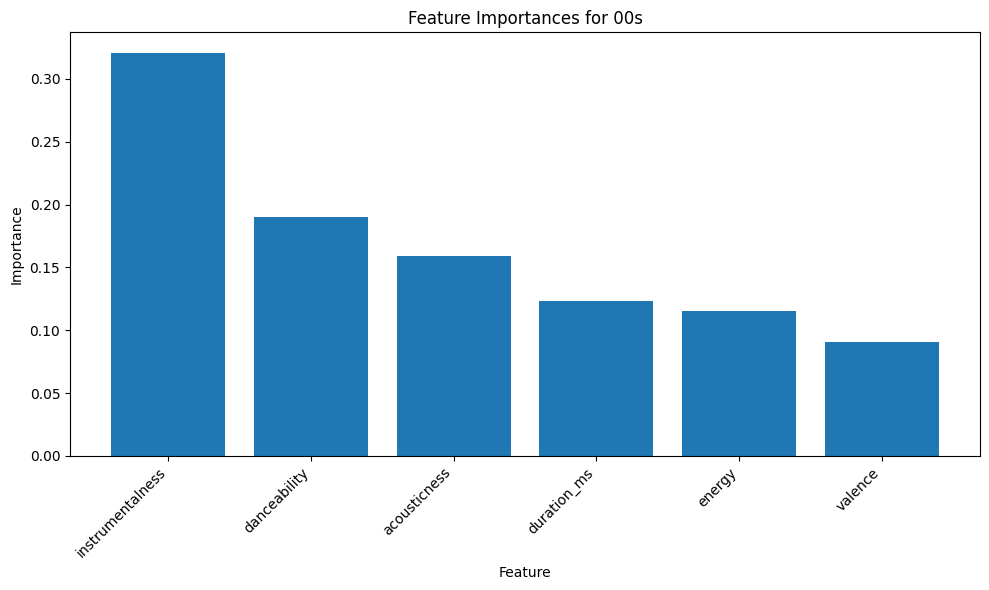

In [24]:
#get feature importance
importances_00s = model.feature_importances_
indices = np.argsort(importances_00s)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances for 00s")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.bar(range(len(importances_00s)), importances_00s[indices])
plt.xticks(range(len(importances_00s)), [feature_set[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../../Figures/feature_importance_00s.png')
plt.show()

10s Features


In [25]:
data_10s = pd.read_csv('../../Data/dataset-of-10s.csv')
columns_corr = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
                'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target']


# Calculate correlations and identify best features
data_num = data_10s[columns_corr]
#data_10s.head()

In [26]:
#feature selection with sequential feature selector
#get features with correlation > 0.05 with target

columns_corr = data_num.columns[data_num.corr()['target'].abs() > 0.05].tolist()
columns_corr.remove('target')
print("Columns with correlation > 0.05:", columns_corr)
X = data_num[columns_corr]
y = data_num['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Columns with correlation > 0.05: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'duration_ms', 'time_signature', 'chorus_hit', 'sections']


In [27]:
model = RandomForestClassifier(max_depth=15, min_samples_leaf=1, min_samples_split=4, n_estimators=300, random_state=42) #get the best parameters from grid search
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
sfs = SequentialFeatureSelector(model, direction='forward')
sfs.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
#print the selected features
print("Selected features:", sfs.get_support())
feature_set = [col for col, selected in zip(columns_corr, sfs.get_support()) if selected]
print("Selected features:", feature_set)

Selected features: [False  True  True  True  True  True False  True False False False False]
Selected features: ['energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence']


In [ ]:
X = all_features_df[feature_set]
y = all_features_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1826
           1       0.77      0.87      0.82      1732

    accuracy                           0.81      3558
   macro avg       0.82      0.81      0.81      3558
weighted avg       0.82      0.81      0.81      3558

Confusion Matrix:
[[1382  444]
 [ 224 1508]]
Accuracy: 0.8122540753232153
F1 Score: 0.8118424549671838


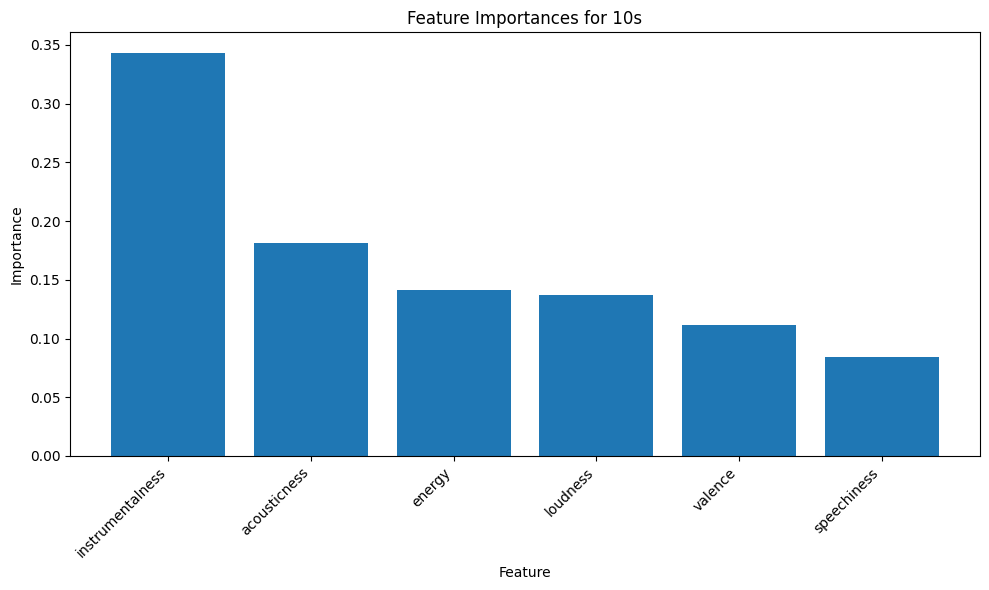

In [ ]:
#get feature importance
importances_10s = model.feature_importances_
indices = np.argsort(importances_10s)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances for 10s")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.bar(range(len(importances_10s)), importances_10s[indices])
plt.xticks(range(len(importances_10s)), [feature_set[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('../../Figures/feature_importance_10s.png')

Compare importances off different decades in a plot

NameError: name 'importances_90s' is not defined

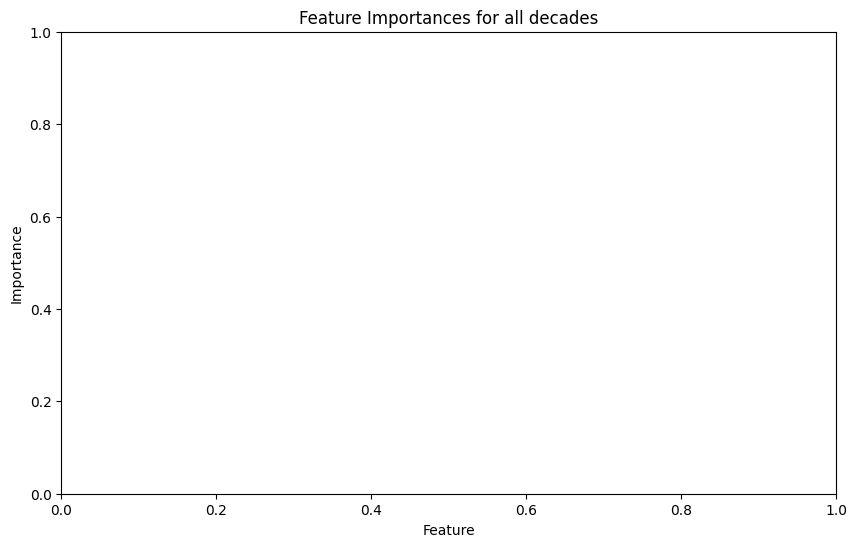

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Feature Importances for all decades")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.bar(range(len(importances_90s)), importances_90s[indices])
plt.bar(range(len(importances_00s)), importances_00s[indices])
plt.bar(range(len(importances_10s)), importances_10s[indices])
plt.tight_layout()
plt.savefig('../../Figures/feature_importance_all_decades.png')